In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import umap
from sklearn.preprocessing import LabelEncoder

In [43]:
df = pd.read_csv('00_authors.csv').rename(columns={'Unnamed: 0': 'Author'}).drop(columns='BookID')
authors = df['Author'].values  # n_samples-length array
X = df.drop(columns=['Author'])

# UMAP dimensionality reduction
umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42, n_jobs=1)
X_umap = pd.DataFrame(umap_model.fit_transform(X))

In [44]:
## Poisson EM Algorithm
def poisson_mixture_em(X, K, max_iter=100, tol=1e-4, eps=1e-9, random_state=0):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    N, d = X.shape

    # Initialization
    idx = rng.choice(N, K, replace=False)
    lam = np.maximum(X[idx].astype(float), eps)     # Initialize as sample means
    w = np.ones(K) / K                              # Uniform mixture weights

    ll_trace = []
    ll_prev = -np.inf

    for it in range(max_iter):
        # E-step
        ## s_ik = log w_k + sum_j x_ij log lam_kj - sum_j lam_kj
        s = X @ np.log(lam.T) - lam.sum(axis=1)     # (N,K)
        s += np.log(w)
        m = s.max(axis=1, keepdims=True)
        gamma = np.exp(s - m)                       # stabilize softmax
        gamma /= gamma.sum(axis=1, keepdims=True)

        # M-step
        Nk = gamma.sum(axis=0) + eps
        w = Nk / N
        lam = (gamma.T @ X) / Nk[:, None]
        lam = np.maximum(lam, eps)

        # Log-likelihood
        ll = np.sum(m + np.log(np.exp(s - m).sum(axis=1)))
        ll_trace.append(ll)

        if abs(ll - ll_prev) < tol:
            break
        ll_prev = ll
    
    return w, lam, gamma, ll_trace

In [46]:
K = 4
w, lam, gamma, ll = poisson_mixture_em(X, K)
labels = gamma.argmax(axis=1) # hard assignments
posterior_uncertainty = 1 - gamma.max(axis=1)

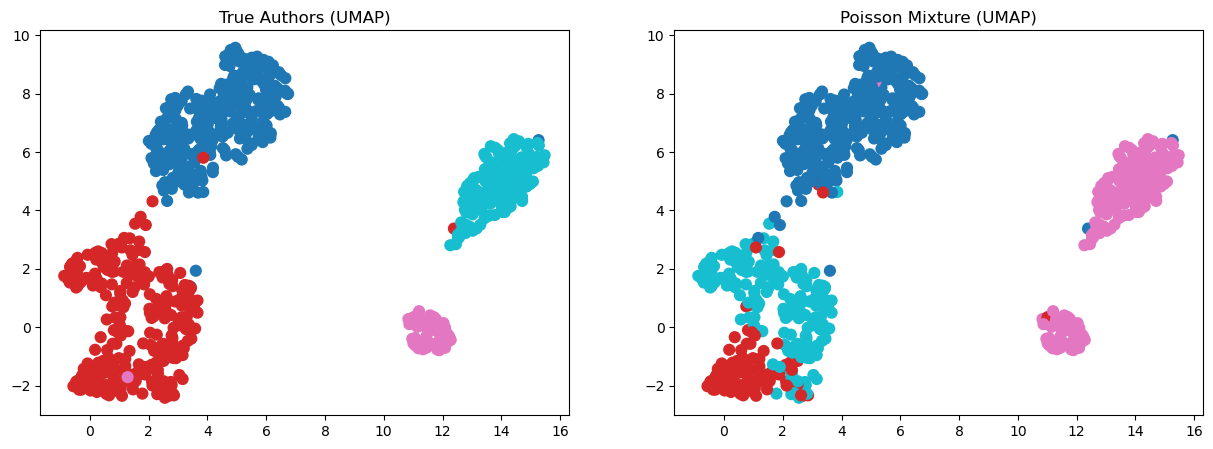

In [48]:
le = LabelEncoder()
author_encoded = le.fit_transform(authors)

fig, axes = plt.subplots(1,2,figsize=(15,5))

axes[0].scatter(X_umap[0], X_umap[1], c=author_encoded, cmap='tab10', s=60)
axes[0].set_title("True Authors (UMAP)")

axes[1].scatter(X_umap[0], X_umap[1], c=labels, cmap='tab10', s=60)
axes[1].set_title("Poisson Mixture (UMAP)")

plt.show()
